# Preprocessing MCTNet — Partie 2
## Arkansas & California + Covariables environnementales

Pipeline corrigé : **split d'abord → StandardScaler fitté sur train uniquement** (pas de data leak).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print('GPU disponible :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))

import os, sys



Mounted at /content/drive
GPU disponible : True
GPU : Tesla T4


## Cellule 1 — Imports

In [23]:
import numpy as np
import pandas as pd
import os
import warnings
import pickle
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print('NumPy  :', np.__version__)
print('Pandas :', pd.__version__)

NumPy  : 2.0.2
Pandas : 2.2.2


## Cellule 2 — Configuration
> ⚠️ Modifiez les chemins CSV et OUT_DIR selon votre machine

In [24]:
import numpy as np
import pandas as pd
import os
import warnings
import pickle
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler

# ── Adapte ces chemins à ton Drive ──────────────────────────────
ARK_CSV = '/content/drive/MyDrive/data_part2/arkansas_final.csv'
CAL_CSV = '/content/drive/MyDrive/data_part2/California_10k_targeted.csv'
OUT_DIR = '/content/drive/MyDrive/data_part2/TES_preprocessesd'
# ────────────────────────────────────────────────────────────────

BANDS   = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
N_TIMES, N_BANDS = 36, 10
SCALE   = 10000.0
IDX     = {band: i for i, band in enumerate(BANDS)}

ARK_LABELS = {0:'Corn', 1:'Cotton', 2:'Rice', 3:'Soybeans', 4:'Others'}
CAL_LABELS = {0:'Rice', 1:'Alfalfa', 2:'Grapes', 3:'Almonds', 4:'Pistachios', 5:'Others'}

SAMPLES_PER_CLASS = 300
VAL_RATIO         = 0.2
RANDOM_SEED       = 42

os.makedirs(OUT_DIR, exist_ok=True)
print('OUT_DIR :', OUT_DIR)

OUT_DIR : /content/drive/MyDrive/data_part2/TES_preprocessesd


## Cellule 3 — Construction de l'ordre des 360 colonnes S2

Format GEE exporté : `B2` (t=0), `B2_1` (t=1), ..., `B2_35` (t=35)

In [25]:
def build_spectral_cols():
    cols = []
    for t in range(N_TIMES):
        for band in BANDS:
            cols.append(band if t == 0 else f'{band}_{t}')
    return cols

spectral_cols = build_spectral_cols()


print(f'Colonnes spectrales : {len(spectral_cols)}')
print(f'Temps 0  : {spectral_cols[:10]}')
print(f'Temps 1  : {spectral_cols[10:20]}')
print(f'Temps 35 : {spectral_cols[-10:]}')


Colonnes spectrales : 360
Temps 0  : ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
Temps 1  : ['B2_1', 'B3_1', 'B4_1', 'B5_1', 'B6_1', 'B7_1', 'B8_1', 'B8A_1', 'B11_1', 'B12_1']
Temps 35 : ['B2_35', 'B3_35', 'B4_35', 'B5_35', 'B6_35', 'B7_35', 'B8_35', 'B8A_35', 'B11_35', 'B12_35']


## Cellule 4 — Chargement & inspection des CSV

In [26]:
ark_df = pd.read_csv(ARK_CSV)
cal_df = pd.read_csv(CAL_CSV)

# Colonnes covariables détectées dynamiquement (utilisées dans la suite)
cov_columns_ark = [c for c in ark_df.columns if (
    '_T_c_' in c or '_P_mm_' in c or '_RH_' in c
)] + ['ph_b0', 'oc_b0', 'texture_b0', 'elevation', 'landforms']

cov_columns_cal = [c for c in cal_df.columns if (
    '_T_c_' in c or '_P_mm_' in c or '_RH_' in c
)] + ['ph_b0', 'oc_b0', 'texture_b0', 'elevation', 'landforms']

for name, df, label_map, cov_cols in [
    ('ARKANSAS',   ark_df, ARK_LABELS, cov_columns_ark),
    ('CALIFORNIA', cal_df, CAL_LABELS, cov_columns_cal),
]:
    print(f'=== {name} ===')
    print(f'  Shape : {df.shape}')
    print(f'  Distribution des labels :')
    for cls, count in df['label'].value_counts().sort_index().items():
        label_name = label_map.get(int(cls), '?')
        print(f'    Classe {int(cls)} ({label_name:12s}) : {count:5d} ({count/len(df)*100:.1f}%)')
    missing_cov = [c for c in cov_cols if c not in df.columns]
    if missing_cov:
        print(f'  ⚠️  COLONNES MANQUANTES : {missing_cov}')
    else:
        print(f'  ✅ Toutes les covariables présentes ({len(cov_cols)} colonnes)')
    print()

=== ARKANSAS ===
  Shape : (10000, 476)
  Distribution des labels :
    Classe 0 (Corn        ) :  2000 (20.0%)
    Classe 1 (Cotton      ) :  2000 (20.0%)
    Classe 2 (Rice        ) :  2000 (20.0%)
    Classe 3 (Soybeans    ) :  2000 (20.0%)
    Classe 4 (Others      ) :  2000 (20.0%)
  ✅ Toutes les covariables présentes (5 colonnes)

=== CALIFORNIA ===
  Shape : (10000, 474)
  Distribution des labels :
    Classe 0 (Rice        ) :   811 (8.1%)
    Classe 1 (Alfalfa     ) :  2159 (21.6%)
    Classe 2 (Grapes      ) :  1572 (15.7%)
    Classe 3 (Almonds     ) :  1841 (18.4%)
    Classe 4 (Pistachios  ) :  1551 (15.5%)
    Classe 5 (Others      ) :  2066 (20.7%)
  ✅ Toutes les covariables présentes (5 colonnes)



## Cellule 5 — Extraction S2 → shape `(N, 10, 36)`

Valeurs brutes (× 10000), pas encore normalisées.

In [28]:
def extract_raw(df):
    X = df[spectral_cols].values.astype(np.float32)   # (N, 360)
    X = X.reshape(len(X), N_TIMES, N_BANDS)            # (N, 36, 10)
    X = X.transpose(0, 2, 1)                            # (N, 10, 36)
    return X

ark_raw = extract_raw(ark_df)
cal_raw = extract_raw(cal_df)

print('Raw Arkansas  :', ark_raw.shape, '  Min:', ark_raw.min(), '  Max:', ark_raw.max())
print('Raw California:', cal_raw.shape, '  Min:', cal_raw.min(), '  Max:', cal_raw.max())

Raw Arkansas  : (10000, 10, 36)   Min: 0.0   Max: 12986.0
Raw California: (10000, 10, 36)   Min: 0.0   Max: 9602.0


## Cellule 6 — Construction du masque (Input 2)

`1 = valide`, `0 = manquant` — utilisé par le module ALPE du MCTNet

In [29]:
def build_mask(X_raw):
    all_zero = (X_raw == 0).all(axis=1)       # (N, 36) — True si toutes bandes = 0
    mask = (~all_zero).astype(np.float32)      # (N, 36) — 1=valide, 0=manquant
    return mask

ark_mask = build_mask(ark_raw)
cal_mask = build_mask(cal_raw)

for name, mask in [('Arkansas', ark_mask), ('California', cal_mask)]:
    miss_rate   = (mask == 0).mean() * 100
    miss_per_px = (mask == 0).sum(axis=1)
    print(f'=== {name} ===')
    print(f'  Taux manquant global  : {miss_rate:.2f}%')
    print(f'  Px sans manquant      : {(miss_per_px == 0).sum()} ({(miss_per_px==0).mean()*100:.1f}%)')
    print(f'  Px avec > 30% manq.   : {(miss_per_px > 11).sum()} ({(miss_per_px>11).mean()*100:.1f}%)')
    print()



=== Arkansas ===
  Taux manquant global  : 22.71%
  Px sans manquant      : 0 (0.0%)
  Px avec > 30% manq.   : 1254 (12.5%)

=== California ===
  Taux manquant global  : 14.98%
  Px sans manquant      : 9 (0.1%)
  Px avec > 30% manq.   : 1 (0.0%)



## Cellule 7 — Normalisation S2 (÷ 10000)

Constante physique fixe — pas de data leak possible.

In [30]:
def normalize_s2(X_raw):
    return (X_raw / SCALE).astype(np.float32)

ark_input1 = normalize_s2(ark_raw)
cal_input1 = normalize_s2(cal_raw)

for name, X in [('Arkansas', ark_input1), ('California', cal_input1)]:
    print(f'=== {name} — Input1 ===')
    print(f'  Shape  : {X.shape}   dtype : {X.dtype}')
    print(f'  Min    : {X.min():.4f}')
    print(f'  Max    : {X.max():.4f}')
    print(f'  Moyenne: {X[X > 0].mean():.4f}')
    print()

=== Arkansas — Input1 ===
  Shape  : (10000, 10, 36)   dtype : float32
  Min    : 0.0000
  Max    : 1.2986
  Moyenne: 0.2120

=== California — Input1 ===
  Shape  : (10000, 10, 36)   dtype : float32
  Min    : 0.0000
  Max    : 0.9602
  Moyenne: 0.2108



## Cellule 8 — Extraction des labels

In [31]:
ark_labels = ark_df['label'].values.astype(np.int64)
cal_labels = cal_df['label'].values.astype(np.int64)

print('=== LABELS ARKANSAS ===')
for cls, name in ARK_LABELS.items():
    n = (ark_labels == cls).sum()
    print(f'  Classe {cls} ({name:12s}) : {n:5d} ({n/len(ark_labels)*100:.1f}%)')

print()
print('=== LABELS CALIFORNIA ===')
for cls, name in CAL_LABELS.items():
    n = (cal_labels == cls).sum()
    print(f'  Classe {cls} ({name:12s}) : {n:5d} ({n/len(cal_labels)*100:.1f}%)')

=== LABELS ARKANSAS ===
  Classe 0 (Corn        ) :  2000 (20.0%)
  Classe 1 (Cotton      ) :  2000 (20.0%)
  Classe 2 (Rice        ) :  2000 (20.0%)
  Classe 3 (Soybeans    ) :  2000 (20.0%)
  Classe 4 (Others      ) :  2000 (20.0%)

=== LABELS CALIFORNIA ===
  Classe 0 (Rice        ) :   811 (8.1%)
  Classe 1 (Alfalfa     ) :  2159 (21.6%)
  Classe 2 (Grapes      ) :  1572 (15.7%)
  Classe 3 (Almonds     ) :  1841 (18.4%)
  Classe 4 (Pistachios  ) :  1551 (15.5%)
  Classe 5 (Others      ) :  2066 (20.7%)


## Cellule 9 — Extraction des covariables (RAW — sans normalisation)

> ✅ **Correction data leak** : on extrait uniquement les valeurs brutes ici.
> La normalisation StandardScaler se fera **après le split**, sur le train uniquement (Cellule 11).

**3 groupes de covariables :**
- **Climat** : colonnes dynamiques `T_c_`, `P_mm_`, `RH_`
- **Sol** : `ph_b0` (÷10), `oc_b0` (÷5), `texture_b0`
- **Topo** : `elevation`, `landforms`

In [33]:
def extract_covariates_raw(df):
    """
    Extraction des covariables brutes — SANS StandardScaler.
    Seules les conversions d'unités fixes (÷10, ÷5) sont appliquées ici
    car ce sont des constantes physiques, pas des statistiques apprises.
    """

    # APRÈS (corrigé)
    climate_cols = [c for c in df.columns if (
        c.startswith('T_c_') or
        c.startswith('P_mm_') or
        c.startswith('RH_')
    )]
    static_cols = ['ph_b0', 'oc_b0', 'texture_b0', 'elevation', 'landforms']

    print(f'  Nb colonnes climat : {len(climate_cols)}')
    print(f'  Colonnes statiques : {static_cols}')

    cov = df[climate_cols + static_cols].copy().astype(np.float32)

    # Conversions d'unités fixes (pas de statistiques apprises → pas de leak)
    cov['ph_b0'] = cov['ph_b0'] / 10.0
    cov['oc_b0'] = cov['oc_b0'] / 5.0

    return cov.values.astype(np.float32), climate_cols, static_cols


print('=== Arkansas ===')
ark_covars_raw, ark_clim_cols, ark_static_cols = extract_covariates_raw(ark_df)
print(f'  Shape : {ark_covars_raw.shape}')

print()
print('=== California ===')
cal_covars_raw, cal_clim_cols, cal_static_cols = extract_covariates_raw(cal_df)
print(f'  Shape : {cal_covars_raw.shape}')

# ── Indices des groupes ───────────────────────────────────────────────────────
def build_group_indices(clim_cols, static_cols):
    all_cols  = clim_cols + static_cols
    clim_idx  = list(range(len(clim_cols)))
    soil_cols = ['ph_b0', 'oc_b0', 'texture_b0']
    topo_cols = ['elevation', 'landforms']
    soil_idx  = [all_cols.index(c) for c in soil_cols]
    topo_idx  = [all_cols.index(c) for c in topo_cols]
    return clim_idx, soil_idx, topo_idx

ARK_CLIM_IDX, ARK_SOIL_IDX, ARK_TOPO_IDX = build_group_indices(ark_clim_cols, ark_static_cols)
CAL_CLIM_IDX, CAL_SOIL_IDX, CAL_TOPO_IDX = build_group_indices(cal_clim_cols, cal_static_cols)

print()
print(f'Indices Arkansas  — Climat:{len(ARK_CLIM_IDX)}  Sol:{len(ARK_SOIL_IDX)}  Topo:{len(ARK_TOPO_IDX)}')
print(f'Indices California — Climat:{len(CAL_CLIM_IDX)}  Sol:{len(CAL_SOIL_IDX)}  Topo:{len(CAL_TOPO_IDX)}')

=== Arkansas ===
  Nb colonnes climat : 108
  Colonnes statiques : ['ph_b0', 'oc_b0', 'texture_b0', 'elevation', 'landforms']
  Shape : (10000, 113)

=== California ===
  Nb colonnes climat : 108
  Colonnes statiques : ['ph_b0', 'oc_b0', 'texture_b0', 'elevation', 'landforms']
  Shape : (10000, 113)

Indices Arkansas  — Climat:108  Sol:3  Topo:2
Indices California — Climat:108  Sol:3  Topo:2


## Cellule 10 — Vérification d'intégrité (données brutes)

In [34]:
def check_integrity_raw(input1, input2, labels, covars_raw, label_map, name):
    errors = []
    N = len(labels)
    if input1.shape != (N, N_BANDS, N_TIMES):
        errors.append(f'Input1 shape {input1.shape} ≠ attendu ({N}, {N_BANDS}, {N_TIMES})')
    if input2.shape != (N, N_TIMES):
        errors.append(f'Input2 shape {input2.shape} ≠ attendu ({N}, {N_TIMES})')
    if np.isnan(input1).any():
        errors.append('Input1 contient des NaN')
    if np.isnan(covars_raw).any():
        errors.append('Covars contient des NaN')
    if not np.isin(input2, [0, 1]).all():
        errors.append('Input2 contient des valeurs hors {0,1}')
    if set(labels) - set(label_map.keys()):
        errors.append(f'Labels inconnus : {set(labels) - set(label_map.keys())}')

    print(f'=== {name} ===')
    if errors:
        for e in errors: print(f'  ❌ {e}')
    else:
        print(f'  ✅ Input1     : {input1.shape}  float32  [{input1.min():.3f}, {input1.max():.3f}]')
        print(f'  ✅ Input2     : {input2.shape}  float32  {{0,1}}')
        print(f'  ✅ Covars RAW : {covars_raw.shape}  float32  (non normalisées)')
        print(f'  ✅ Labels     : {labels.shape}  classes {sorted(set(labels))}')
    print()

check_integrity_raw(ark_input1, ark_mask, ark_labels, ark_covars_raw, ARK_LABELS, 'Arkansas')
check_integrity_raw(cal_input1, cal_mask, cal_labels, cal_covars_raw, CAL_LABELS, 'California')

=== Arkansas ===
  ✅ Input1     : (10000, 10, 36)  float32  [0.000, 1.299]
  ✅ Input2     : (10000, 36)  float32  {0,1}
  ✅ Covars RAW : (10000, 113)  float32  (non normalisées)
  ✅ Labels     : (10000,)  classes [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

=== California ===
  ✅ Input1     : (10000, 10, 36)  float32  [0.000, 0.960]
  ✅ Input2     : (10000, 36)  float32  {0,1}
  ✅ Covars RAW : (10000, 113)  float32  (non normalisées)
  ✅ Labels     : (10000,)  classes [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]



## Cellule 11 — Split train / val / test + Normalisation ✅

**Ordre correct (sans data leak) :**
1. Split sur données brutes
2. `scaler.fit()` → **train uniquement**
3. `scaler.transform()` → val et test (sans re-fit)

Conforme au paper Table 2 : 300 échantillons par classe pour train+val (80/20), reste = test.

In [35]:
def split_and_normalize(input1, input2, labels, covars_raw, label_map,
                         clim_idx, soil_idx, topo_idx,
                         n_per_class=SAMPLES_PER_CLASS,
                         val_ratio=VAL_RATIO,
                         seed=RANDOM_SEED,
                         region_name=''):
    """
    Pipeline sans data leak :
      1. Split des indices sur données brutes
      2. StandardScaler fitté sur train uniquement
      3. Transform appliqué séparément sur val et test
    """
    np.random.seed(seed)
    train_idx, val_idx, test_idx = [], [], []

    for cls in sorted(label_map.keys()):
        idx_cls = np.where(labels == cls)[0]
        np.random.shuffle(idx_cls)
        n       = min(n_per_class, len(idx_cls))
        tv      = idx_cls[:n]
        n_val   = int(len(tv) * val_ratio)
        n_train = len(tv) - n_val
        train_idx.extend(tv[:n_train].tolist())
        val_idx.extend(tv[n_train:].tolist())
        test_idx.extend(idx_cls[n:].tolist())

    # ── Covariables brutes par split ─────────────────────────────────────────
    cov_train_raw = covars_raw[train_idx]
    cov_val_raw   = covars_raw[val_idx]
    cov_test_raw  = covars_raw[test_idx]

    # ── StandardScaler fitté UNIQUEMENT sur le train ──────────────────────────
    scaler = StandardScaler()
    cov_train = scaler.fit_transform(cov_train_raw).astype(np.float32)  # fit + transform
    cov_val   = scaler.transform(cov_val_raw).astype(np.float32)        # transform only
    cov_test  = scaler.transform(cov_test_raw).astype(np.float32)       # transform only

    # Sauvegarde du scaler (fitté sur train — à utiliser pour toute nouvelle donnée)
    scaler_path = os.path.join(OUT_DIR, f'{region_name}_covar_scaler.pkl')
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f'  ✅ Scaler sauvegardé (fitté sur train uniquement) : {scaler_path}')

    def pack(idx, cov_norm):
        return {
            'input1': input1[idx],
            'input2': input2[idx],
            'covars': cov_norm,
            'labels': labels[idx],
        }

    return (pack(train_idx, cov_train),
            pack(val_idx,   cov_val),
            pack(test_idx,  cov_test),
            scaler)


# ── Arkansas ──────────────────────────────────────────────────────────────────
print('=== Arkansas ===')
ark_train, ark_val, ark_test, ark_scaler = split_and_normalize(
    ark_input1, ark_mask, ark_labels, ark_covars_raw, ARK_LABELS,
    ARK_CLIM_IDX, ARK_SOIL_IDX, ARK_TOPO_IDX,
    region_name='Arkansas')

# ── California ────────────────────────────────────────────────────────────────
print()
print('=== California ===')
cal_train, cal_val, cal_test, cal_scaler = split_and_normalize(
    cal_input1, cal_mask, cal_labels, cal_covars_raw, CAL_LABELS,
    CAL_CLIM_IDX, CAL_SOIL_IDX, CAL_TOPO_IDX,
    region_name='California')

# ── Résumé des splits ─────────────────────────────────────────────────────────
print()
for name, train, val, test in [
    ('Arkansas',   ark_train, ark_val, ark_test),
    ('California', cal_train, cal_val, cal_test),
]:
    print(f'=== {name} ===')
    print(f'  Train : input1{train["input1"].shape}  covars{train["covars"].shape}  y{train["labels"].shape}')
    print(f'  Val   : input1{val["input1"].shape}  covars{val["covars"].shape}  y{val["labels"].shape}')
    print(f'  Test  : input1{test["input1"].shape}  covars{test["covars"].shape}  y{test["labels"].shape}')
    # Vérification : moyenne train ≈ 0, std train ≈ 1 (sanity check scaler)
    print(f'  Covars train — mean={train["covars"].mean():.4f}  std={train["covars"].std():.4f}  (attendu ≈0, ≈1)')
    print(f'  Covars val   — mean={val["covars"].mean():.4f}  std={val["covars"].std():.4f}  (peut dériver légèrement)')
    print(f'  Covars test  — mean={test["covars"].mean():.4f}  std={test["covars"].std():.4f}  (peut dériver légèrement)')
    print()

=== Arkansas ===
  ✅ Scaler sauvegardé (fitté sur train uniquement) : /content/drive/MyDrive/data_part2/TES_preprocessesd/Arkansas_covar_scaler.pkl

=== California ===
  ✅ Scaler sauvegardé (fitté sur train uniquement) : /content/drive/MyDrive/data_part2/TES_preprocessesd/California_covar_scaler.pkl

=== Arkansas ===
  Train : input1(1200, 10, 36)  covars(1200, 113)  y(1200,)
  Val   : input1(300, 10, 36)  covars(300, 113)  y(300,)
  Test  : input1(8500, 10, 36)  covars(8500, 113)  y(8500,)
  Covars train — mean=0.0000  std=1.0000  (attendu ≈0, ≈1)
  Covars val   — mean=-0.0031  std=1.0099  (peut dériver légèrement)
  Covars test  — mean=-0.0055  std=1.0079  (peut dériver légèrement)

=== California ===
  Train : input1(1440, 10, 36)  covars(1440, 113)  y(1440,)
  Val   : input1(360, 10, 36)  covars(360, 113)  y(360,)
  Test  : input1(8200, 10, 36)  covars(8200, 113)  y(8200,)
  Covars train — mean=0.0000  std=0.9956  (attendu ≈0, ≈1)
  Covars val   — mean=-0.0163  std=0.9493  (peut dé

## Cellule 12 — Sauvegarde des fichiers .npy

**Fichiers sauvegardés par split :**
- `input1` → bandes S2 (N, 10, 36)
- `input2` → masque manquants (N, 36)
- `covars_all` → toutes covariables normalisées
- `covars_clim` / `covars_soil` / `covars_topo` → groupes pour ablation study
- `labels` → classes (N,)

In [36]:
def save_split(split_dict, region, split_name, out_dir, clim_idx, soil_idx, topo_idx):
    prefix = os.path.join(out_dir, f'{region}_{split_name}')

    np.save(f'{prefix}_input1.npy',      split_dict['input1'])
    np.save(f'{prefix}_input2.npy',      split_dict['input2'])
    np.save(f'{prefix}_labels.npy',      split_dict['labels'])
    np.save(f'{prefix}_covars_all.npy',  split_dict['covars'])
    np.save(f'{prefix}_covars_clim.npy', split_dict['covars'][:, clim_idx])
    np.save(f'{prefix}_covars_soil.npy', split_dict['covars'][:, soil_idx])
    np.save(f'{prefix}_covars_topo.npy', split_dict['covars'][:, topo_idx])
    # Après les np.save existants, ajouter :
    np.save(f'{prefix}_covars_clim_soil.npy', split_dict['covars'][:, clim_idx + soil_idx])
    np.save(f'{prefix}_covars_clim_topo.npy', split_dict['covars'][:, clim_idx + topo_idx])
    np.save(f'{prefix}_covars_soil_topo.npy', split_dict['covars'][:, soil_idx + topo_idx])



    print(f'  {split_name:5s} → input1:{split_dict["input1"].shape}  '
          f'covars_all:{split_dict["covars"].shape}  '
          f'clim:{split_dict["covars"][:, clim_idx].shape}  '
          f'soil:{split_dict["covars"][:, soil_idx].shape}  '
          f'topo:{split_dict["covars"][:, topo_idx].shape}  '
          f'labels:{split_dict["labels"].shape}')


print('=== Sauvegarde Arkansas ===')
for split_name, split_dict in [('train', ark_train), ('val', ark_val), ('test', ark_test)]:
    save_split(split_dict, 'Arkansas', split_name, OUT_DIR,
               ARK_CLIM_IDX, ARK_SOIL_IDX, ARK_TOPO_IDX)

print()
print('=== Sauvegarde California ===')
for split_name, split_dict in [('train', cal_train), ('val', cal_val), ('test', cal_test)]:
    save_split(split_dict, 'California', split_name, OUT_DIR,
               CAL_CLIM_IDX, CAL_SOIL_IDX, CAL_TOPO_IDX)

print()
print('✅ Tous les fichiers .npy sauvegardés dans :', OUT_DIR)

=== Sauvegarde Arkansas ===
  train → input1:(1200, 10, 36)  covars_all:(1200, 113)  clim:(1200, 108)  soil:(1200, 3)  topo:(1200, 2)  labels:(1200,)
  val   → input1:(300, 10, 36)  covars_all:(300, 113)  clim:(300, 108)  soil:(300, 3)  topo:(300, 2)  labels:(300,)
  test  → input1:(8500, 10, 36)  covars_all:(8500, 113)  clim:(8500, 108)  soil:(8500, 3)  topo:(8500, 2)  labels:(8500,)

=== Sauvegarde California ===
  train → input1:(1440, 10, 36)  covars_all:(1440, 113)  clim:(1440, 108)  soil:(1440, 3)  topo:(1440, 2)  labels:(1440,)
  val   → input1:(360, 10, 36)  covars_all:(360, 113)  clim:(360, 108)  soil:(360, 3)  topo:(360, 2)  labels:(360,)
  test  → input1:(8200, 10, 36)  covars_all:(8200, 113)  clim:(8200, 108)  soil:(8200, 3)  topo:(8200, 2)  labels:(8200,)

✅ Tous les fichiers .npy sauvegardés dans : /content/drive/MyDrive/data_part2/TES_preprocessesd


## Cellule 13 — Vérification finale (rechargement des .npy)

In [37]:
print('='*65)
print('  VÉRIFICATION FINALE — RECHARGEMENT DES FICHIERS')
print('='*65)

for region, label_map in [('Arkansas', ARK_LABELS), ('California', CAL_LABELS)]:
    print(f'\n--- {region} ---')
    for split in ['train', 'val', 'test']:
        X   = np.load(os.path.join(OUT_DIR, f'{region}_{split}_input1.npy'))
        M   = np.load(os.path.join(OUT_DIR, f'{region}_{split}_input2.npy'))
        Ca  = np.load(os.path.join(OUT_DIR, f'{region}_{split}_covars_all.npy'))
        Cc  = np.load(os.path.join(OUT_DIR, f'{region}_{split}_covars_clim.npy'))
        Cs  = np.load(os.path.join(OUT_DIR, f'{region}_{split}_covars_soil.npy'))
        Ct  = np.load(os.path.join(OUT_DIR, f'{region}_{split}_covars_topo.npy'))
        Ccs = np.load(os.path.join(OUT_DIR, f'{region}_{split}_covars_clim_soil.npy'))  # ← ajout
        Cct = np.load(os.path.join(OUT_DIR, f'{region}_{split}_covars_clim_topo.npy'))  # ← ajout
        Cst = np.load(os.path.join(OUT_DIR, f'{region}_{split}_covars_soil_topo.npy'))  # ← ajout
        y   = np.load(os.path.join(OUT_DIR, f'{region}_{split}_labels.npy'))
        print(f'  {split:5s}: X{X.shape}  M{M.shape}  '
              f'all{Ca.shape}  clim{Cc.shape}  soil{Cs.shape}  topo{Ct.shape}  '
              f'clim_soil{Ccs.shape}  clim_topo{Cct.shape}  soil_topo{Cst.shape}  '  # ← ajout
              f'y{y.shape}')

  VÉRIFICATION FINALE — RECHARGEMENT DES FICHIERS

--- Arkansas ---
  train: X(1200, 10, 36)  M(1200, 36)  all(1200, 113)  clim(1200, 108)  soil(1200, 3)  topo(1200, 2)  clim_soil(1200, 111)  clim_topo(1200, 110)  soil_topo(1200, 5)  y(1200,)
  val  : X(300, 10, 36)  M(300, 36)  all(300, 113)  clim(300, 108)  soil(300, 3)  topo(300, 2)  clim_soil(300, 111)  clim_topo(300, 110)  soil_topo(300, 5)  y(300,)
  test : X(8500, 10, 36)  M(8500, 36)  all(8500, 113)  clim(8500, 108)  soil(8500, 3)  topo(8500, 2)  clim_soil(8500, 111)  clim_topo(8500, 110)  soil_topo(8500, 5)  y(8500,)

--- California ---
  train: X(1440, 10, 36)  M(1440, 36)  all(1440, 113)  clim(1440, 108)  soil(1440, 3)  topo(1440, 2)  clim_soil(1440, 111)  clim_topo(1440, 110)  soil_topo(1440, 5)  y(1440,)
  val  : X(360, 10, 36)  M(360, 36)  all(360, 113)  clim(360, 108)  soil(360, 3)  topo(360, 2)  clim_soil(360, 111)  clim_topo(360, 110)  soil_topo(360, 5)  y(360,)
  test : X(8200, 10, 36)  M(8200, 36)  all(8200, 113)  cl

## Cellule 14 — Visualisations
### 14a. Taux de données manquantes par pas de temps

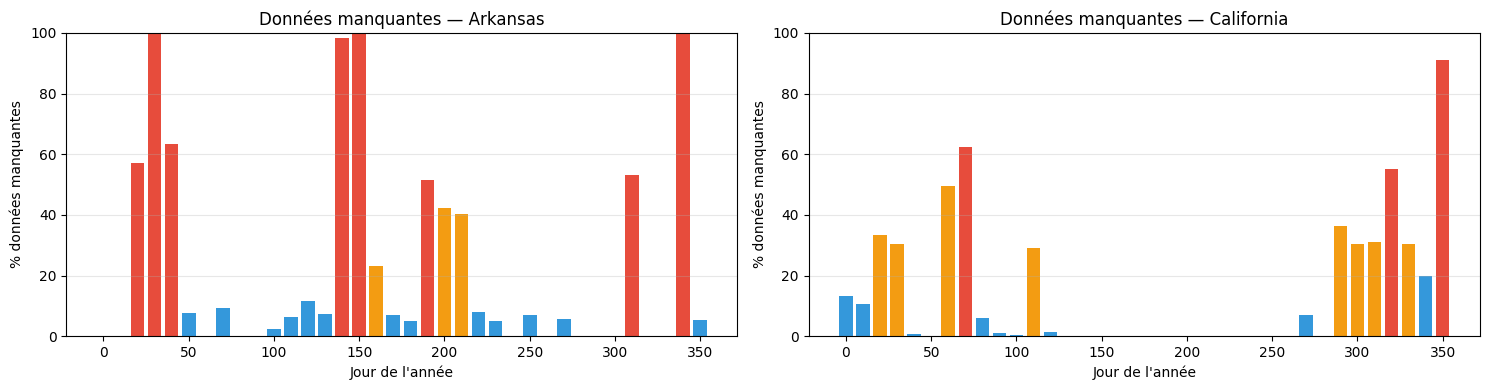

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, M_data, title in zip(axes, [ark_mask, cal_mask], ['Arkansas', 'California']):
    miss_pct = (M_data == 0).mean(axis=0) * 100
    days  = [t * 10 for t in range(N_TIMES)]
    colors = ['#E74C3C' if v > 50 else '#F39C12' if v > 20 else '#3498DB' for v in miss_pct]
    ax.bar(days, miss_pct, width=8, color=colors)
    ax.set_xlabel("Jour de l'année")
    ax.set_ylabel('% données manquantes')
    ax.set_title(f'Données manquantes — {title}')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('missing_data_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### 14b. Profils NDVI moyens par classe (Figure 2 du paper)

⚠️ NDVI calculé pour visualisation uniquement — pas une feature du modèle.

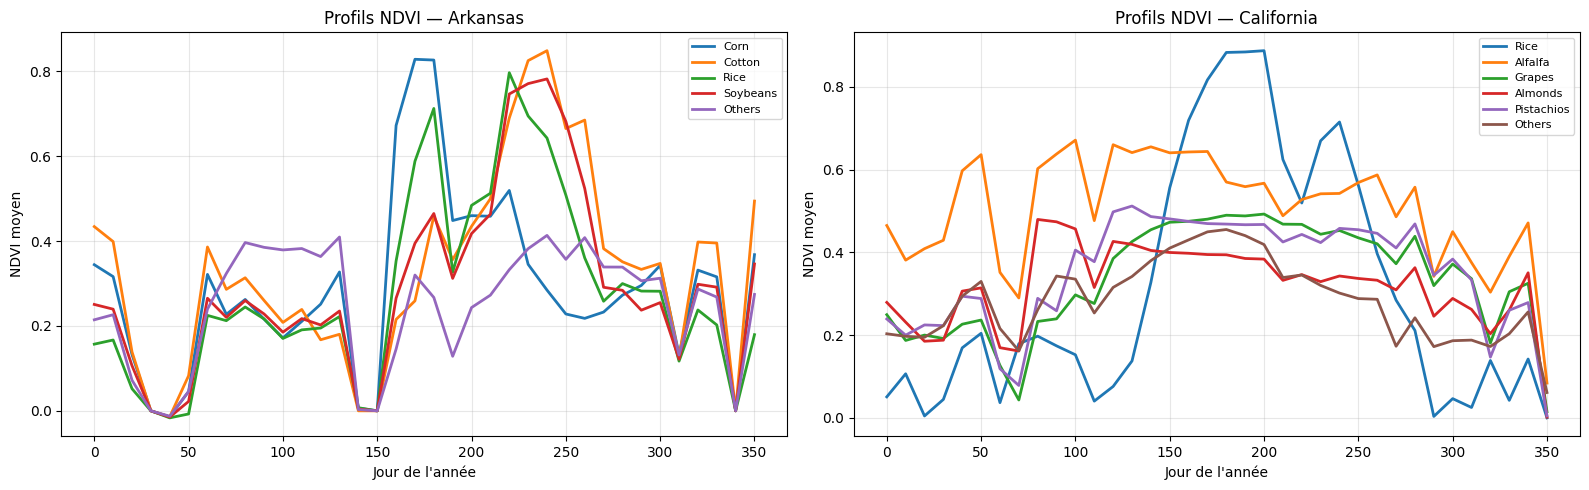

In [39]:
def compute_ndvi(X_raw, mask):
    eps  = 1e-8
    NIR  = X_raw[:, IDX['B8'],  :]
    Red  = X_raw[:, IDX['B4'],  :]
    ndvi = (NIR - Red) / (NIR + Red + eps)
    return ndvi * mask

ark_ndvi = compute_ndvi(ark_raw, ark_mask)
cal_ndvi = compute_ndvi(cal_raw, cal_mask)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
days = [t * 10 for t in range(N_TIMES)]

for ax, ndvi_data, labels_data, label_map, title in [
    (axes[0], ark_ndvi, ark_labels, ARK_LABELS, 'Arkansas'),
    (axes[1], cal_ndvi, cal_labels, CAL_LABELS, 'California'),
]:
    for cls, cls_name in label_map.items():
        idx = labels_data == cls
        mean_ndvi = ndvi_data[idx].mean(axis=0)
        ax.plot(days, mean_ndvi, label=cls_name, linewidth=2)
    ax.set_xlabel("Jour de l'année")
    ax.set_ylabel('NDVI moyen')
    ax.set_title(f'Profils NDVI — {title}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ndvi_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### 14c. Distribution des bandes normalisées (pixels valides)

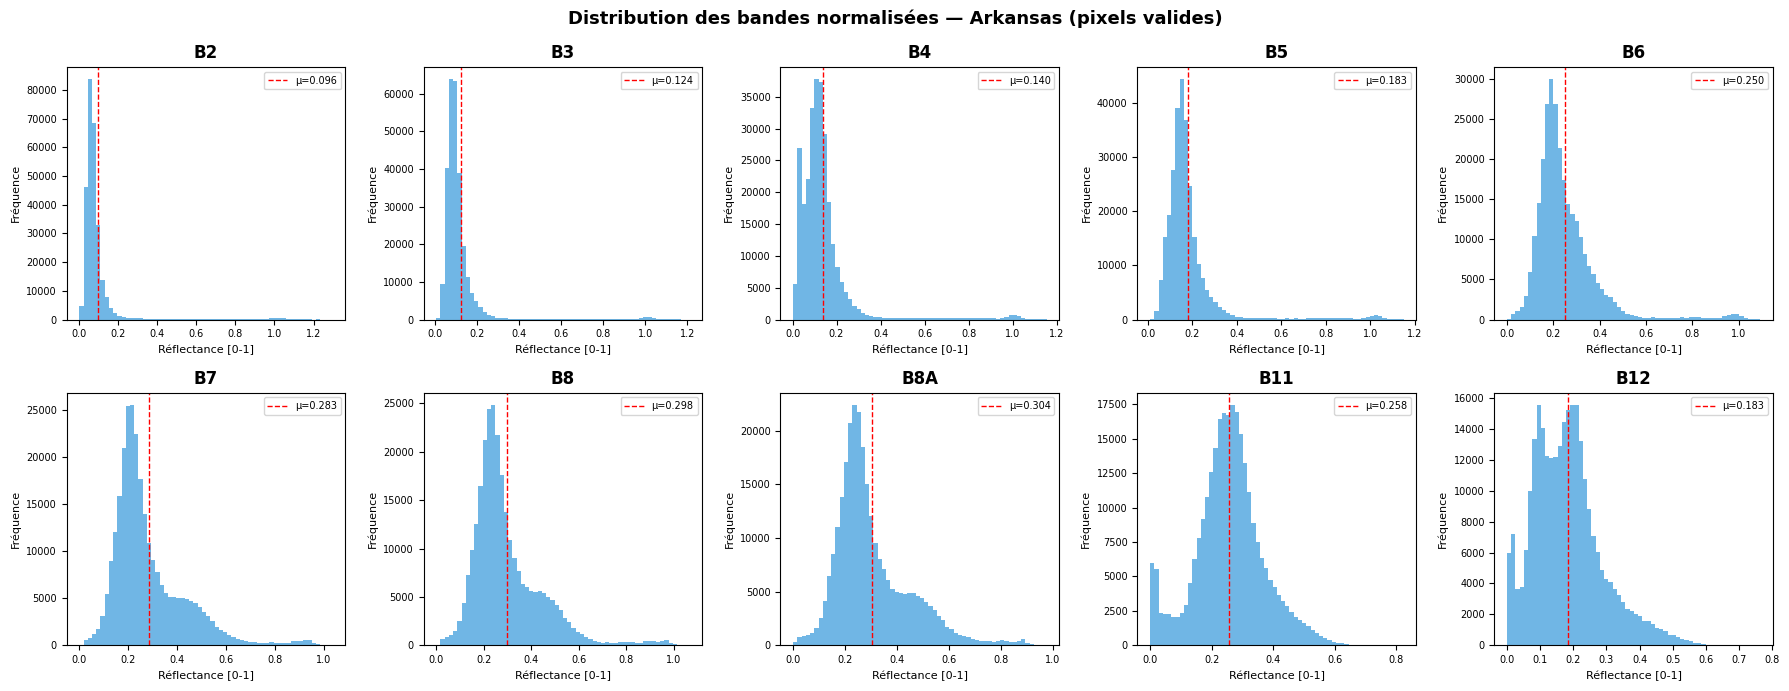

In [40]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Distribution des bandes normalisées — Arkansas (pixels valides)',
             fontsize=13, fontweight='bold')

for i, (band_name, ax) in enumerate(zip(BANDS, axes.flatten())):
    band_data    = ark_input1[:, i, :]
    valid_pixels = band_data[ark_mask == 1]
    ax.hist(valid_pixels, bins=60, color='#3498DB', alpha=0.7, edgecolor='none')
    ax.set_title(f'{band_name}', fontweight='bold')
    ax.set_xlabel('Réflectance [0-1]', fontsize=8)
    ax.set_ylabel('Fréquence', fontsize=8)
    mean_v = valid_pixels.mean()
    ax.axvline(mean_v, color='red', linestyle='--', linewidth=1, label=f'μ={mean_v:.3f}')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('band_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 14d. Distribution des covariables normalisées par split

Vérifie visuellement que train ≈ N(0,1), et que val/test suivent une distribution similaire.

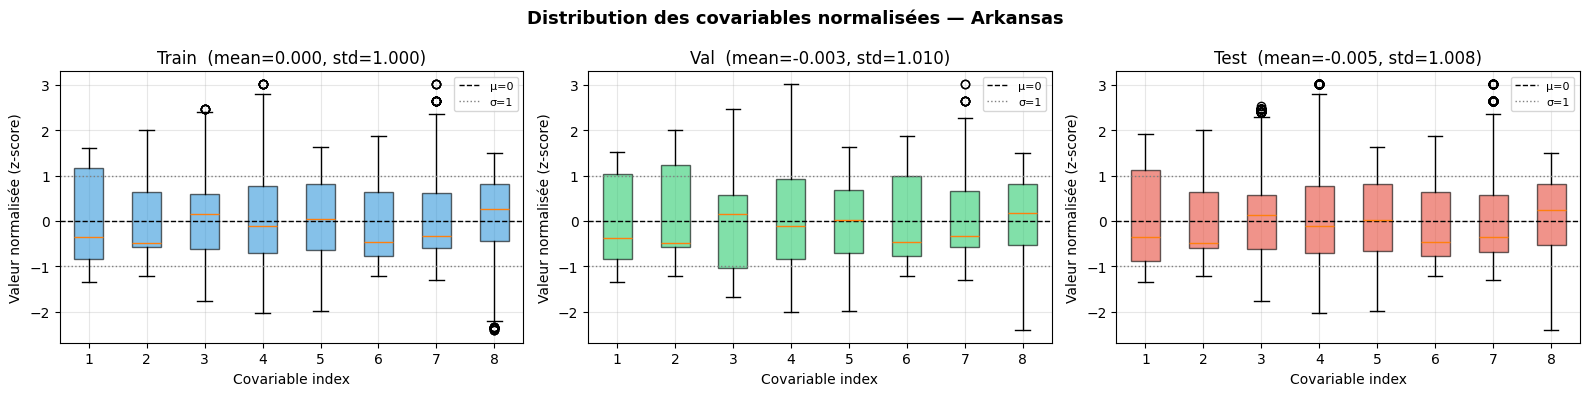

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribution des covariables normalisées — Arkansas', fontsize=13, fontweight='bold')

for ax, split_name, split_dict, color in [
    (axes[0], 'Train', ark_train, '#3498DB'),
    (axes[1], 'Val',   ark_val,   '#2ECC71'),
    (axes[2], 'Test',  ark_test,  '#E74C3C'),
]:
    cov = split_dict['covars']
    ax.boxplot([cov[:, i] for i in range(min(8, cov.shape[1]))],
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.axhline(0,  color='black', linestyle='--', lw=1, label='μ=0')
    ax.axhline(1,  color='gray',  linestyle=':',  lw=1, label='σ=1')
    ax.axhline(-1, color='gray',  linestyle=':',  lw=1)
    ax.set_title(f'{split_name}  (mean={cov.mean():.3f}, std={cov.std():.3f})')
    ax.set_xlabel('Covariable index')
    ax.set_ylabel('Valeur normalisée (z-score)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('covar_distributions_splits.png', dpi=150, bbox_inches='tight')
plt.show()

## Cellule 15 — Résumé complet

In [42]:
print('='*65)
print('   RÉSUMÉ DU PREPROCESSING MCTNet — PARTIE 2')
print('='*65)

for region, X, M, y, cov_raw, train, val, test, label_map, scaler in [
    ('Arkansas',   ark_input1, ark_mask, ark_labels, ark_covars_raw,
     ark_train, ark_val, ark_test, ARK_LABELS, ark_scaler),
    ('California', cal_input1, cal_mask, cal_labels, cal_covars_raw,
     cal_train, cal_val, cal_test, CAL_LABELS, cal_scaler),
]:
    print(f'\n  {region}')
    print(f'  ┌──────────────────────────────────────────────────────────')
    print(f'  │ Input1 (S2)     : {X.shape}  float32  [0~1]  (÷10000)')
    print(f'  │ Input2 (masque) : {M.shape}   float32  {{0,1}}')
    print(f'  │   → Taux manquant : {(M==0).mean()*100:.2f}%')
    print(f'  │ Covariables RAW : {cov_raw.shape}  float32')
    print(f'  │ Labels          : {y.shape}')
    print(f'  ├──────────────────────────────────────────────────────────')
    print(f'  │ SPLIT (StandardScaler fitté sur train uniquement) :')
    print(f'  │   Train : input1{train["input1"].shape}  cov{train["covars"].shape}  y{train["labels"].shape}')
    print(f'  │   Val   : input1{val["input1"].shape}  cov{val["covars"].shape}  y{val["labels"].shape}')
    print(f'  │   Test  : input1{test["input1"].shape}  cov{test["covars"].shape}  y{test["labels"].shape}')
    print(f'  │ Scaler mean (train) : {scaler.mean_[:3].round(3)} ...')
    print(f'  │ Scaler std  (train) : {scaler.scale_[:3].round(3)} ...')
    print(f'  └──────────────────────────────────────────────────────────')

print()
print('Fichiers .npy générés par split (train/val/test) :')
print('  *_input1.npy      → (N, 10, 36)  bandes S2')
print('  *_input2.npy      → (N, 36)      masque manquants')
print('  *_covars_all.npy  → (N, K)       toutes covariables normalisées')
print('  *_covars_clim.npy → (N, K_c)     climat seul   [ablation]')
print('  *_covars_soil.npy → (N, 3)       sol seul      [ablation]')
print('  *_covars_topo.npy → (N, 2)       topo seul     [ablation]')
print('  *_covars_clim_soil.npy → (N, 111)  climat + sol')   # ← ajout
print('  *_covars_clim_topo.npy → (N, 110)  climat + topo')  # ← ajout
print('  *_covars_soil_topo.npy → (N, 5)    sol + topo')
print('  *_labels.npy      → (N,)         classes')
print('  *_covar_scaler.pkl → StandardScaler (fitté sur train)')
print()
print('✅  Prêt pour MCTNet Partie 2 !')

   RÉSUMÉ DU PREPROCESSING MCTNet — PARTIE 2

  Arkansas
  ┌──────────────────────────────────────────────────────────
  │ Input1 (S2)     : (10000, 10, 36)  float32  [0~1]  (÷10000)
  │ Input2 (masque) : (10000, 36)   float32  {0,1}
  │   → Taux manquant : 22.71%
  │ Covariables RAW : (10000, 113)  float32
  │ Labels          : (10000,)
  ├──────────────────────────────────────────────────────────
  │ SPLIT (StandardScaler fitté sur train uniquement) :
  │   Train : input1(1200, 10, 36)  cov(1200, 113)  y(1200,)
  │   Val   : input1(300, 10, 36)  cov(300, 113)  y(300,)
  │   Test  : input1(8500, 10, 36)  cov(8500, 113)  y(8500,)
  │ Scaler mean (train) : [3.108 0.574 3.979] ...
  │ Scaler std  (train) : [1.031 0.428 0.871] ...
  └──────────────────────────────────────────────────────────

  California
  ┌──────────────────────────────────────────────────────────
  │ Input1 (S2)     : (10000, 10, 36)  float32  [0~1]  (÷10000)
  │ Input2 (masque) : (10000, 36)   float32  {0,1}
  │   → T